# 1. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
import spacy
from tqdm.auto import tqdm

# 2. Upload File

In [2]:
DATA_FILE = 'fcc_news_release_metadata_with_body_text.parquet'

df = pd.read_parquet(DATA_FILE)

# 3. Exploratory Data Analysis

## 3.1. Data Quality Checks

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3188 entries, 0 to 3187
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   page_title         3188 non-null   object        
 1   full_title         3188 non-null   object        
 2   document_type      3188 non-null   object        
 3   bureaus            3188 non-null   object        
 4   description        1577 non-null   object        
 5   webpage_url        3188 non-null   object        
 6   selected_txt_urls  3188 non-null   object        
 7   all_txt_urls       3188 non-null   object        
 8   all_txt_count      3188 non-null   int64         
 9   released_on        3188 non-null   datetime64[ns]
 10  issued_on          3188 non-null   datetime64[ns]
 11  adopted            822 non-null    datetime64[ns]
 12  filename           3188 non-null   object        
 13  body_text          3188 non-null   object        
 14  body_wor

In [4]:
qc_summary_dict = {
    'number_of_rows': df.shape[0],
    'number_of_columns': df.shape[1],
    'missing_body_text': df['body_text'].isna().sum(),
    'zero_body_word_count': (df['body_word_count'] == 0).sum(),
    'duplicate_filenames': df['filename'].duplicated().sum(),
    'min_released_on': df['released_on'].min(),
    'max_released_on': df['released_on'].max()
}

qc_summary = pd.DataFrame(
    qc_summary_dict.items(),
    columns=['metric', 'value']
)

qc_summary

,metric,value
0,number_of_rows,3188
1,number_of_columns,17
2,missing_body_text,0
3,zero_body_word_count,0
4,duplicate_filenames,0
5,min_released_on,2010-01-05 00:00:00
6,max_released_on,2026-04-30 00:00:00


In [5]:
df['extraction_method'].value_counts(dropna=False).rename('count').to_frame()

,count
extraction_method,
dateline,2207
fallback_body_like_after_front_matter,725
fallback_body_like_after_front_matter_no_city_prefix,245
fallback_body_like_after_front_matter_normal_sentence,5
fallback_after_front_matter,3
fallback_body_like_global,3


In [6]:
df['footer_method'].value_counts(dropna=False).rename('count').to_frame()

,count
footer_method,
footer_marker,3053
no_footer_marker,83
commissioner_office_footer,23
trailing_media_contact,17
office_media_footer,11
twitter,1


## 3.2. Explore Date Variables

In [7]:
df['date'] = df['released_on']
df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.to_period('Q').astype(str)
df['month'] = df['date'].dt.to_period('M').astype(str)

In [8]:
def plot_doc_trend(summary_df, x_label, y_label, tick_every=None):

    cols = summary_df.columns
    period = cols[0]
    var = cols[1]
    num_of_rows = len(summary_df)

    x_pos = range(num_of_rows)

    if tick_every == None:
        tick_every = max(1, num_of_rows // 12)
    
    plt.figure(figsize=(10, 5))
    plt.plot(x_pos, summary_df[var])
    
    plt.title(f'{y_label} by {x_label}')
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    tick_positions = list(range(0, num_of_rows, tick_every))
    
    plt.xticks(
        tick_positions,
        summary_df[period].astype(str).iloc[tick_positions],
        rotation=45,
        ha='right'
    )
    
    plt.tight_layout()
    plt.show()

In [9]:
word_stats_by_year = (
    df.groupby('year')['body_word_count']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .reset_index()
)

word_stats_by_year

,year,count,mean,median,min,max
0,2010,227,437.859031,336.0,39,3293
1,2011,164,502.567073,363.5,90,3067
2,2012,145,525.675862,375.0,69,3390
3,2013,138,434.826087,354.5,69,4079
4,2014,147,357.993197,337.0,85,1317
5,2015,145,397.455172,357.0,71,2228
6,2016,114,385.298246,365.5,49,896
7,2017,187,339.401070,300.0,48,2239
8,2018,195,364.589744,312.0,26,1488
9,2019,218,395.527523,350.5,91,1972


In [10]:
doc_by_year = df.groupby('year').size().rename('n_documents').reset_index()
doc_by_quarter = df.groupby('quarter').size().rename('n_documents').reset_index()
doc_by_month = df.groupby('month').size().rename('n_documents').reset_index()

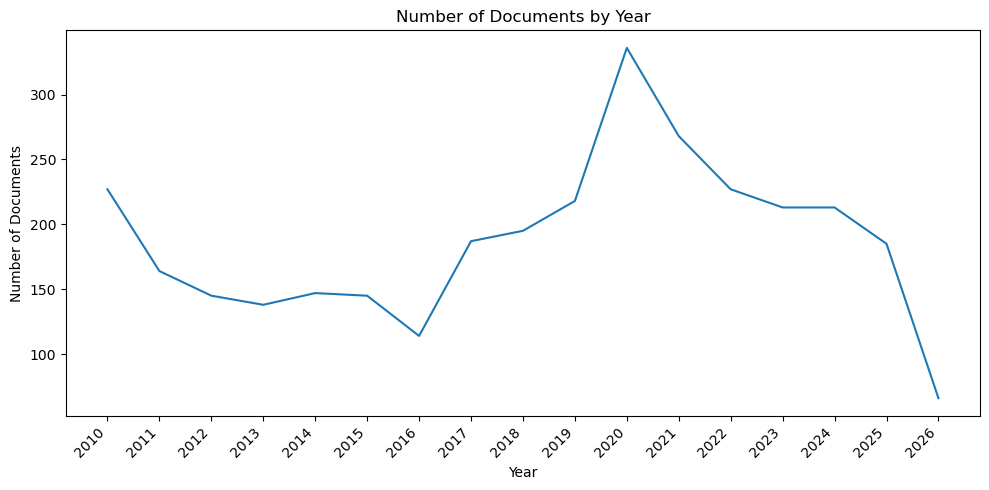

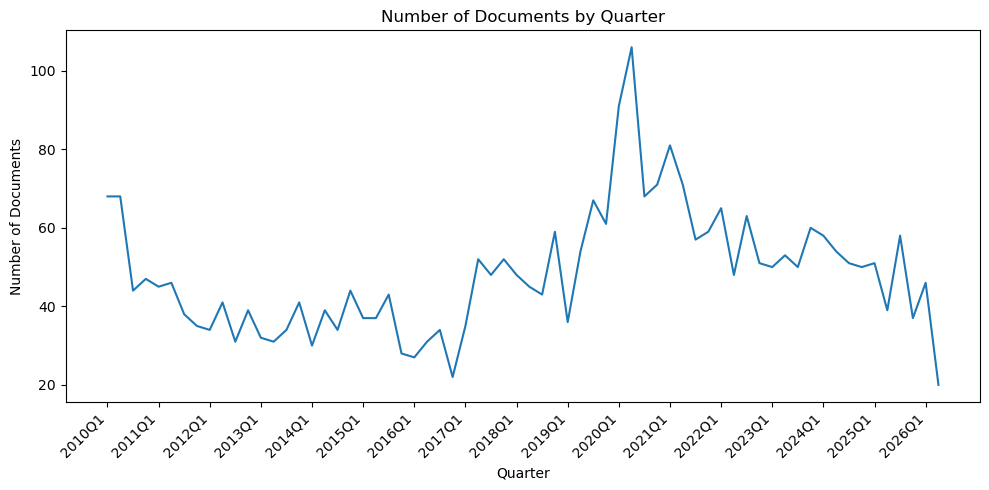

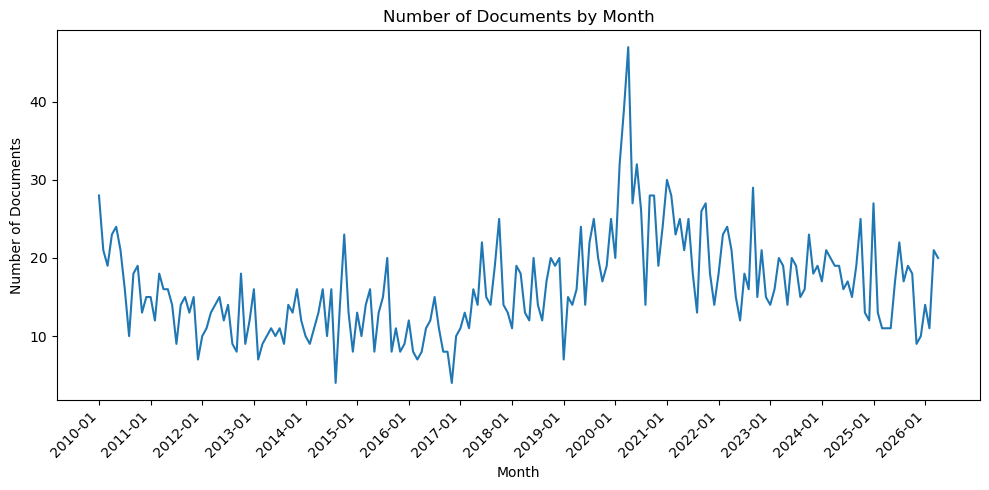

In [11]:
plot_doc_trend(doc_by_year, 'Year', 'Number of Documents', 1)
plot_doc_trend(doc_by_quarter, 'Quarter', 'Number of Documents', 4)
plot_doc_trend(doc_by_month, 'Month', 'Number of Documents', 12)

In [12]:
avg_words_by_year = df.groupby('year')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_quarter = df.groupby('quarter')['body_word_count'].mean().rename('avg_words_per_document').reset_index()
avg_words_by_month = df.groupby('month')['body_word_count'].mean().rename('avg_words_per_document').reset_index()

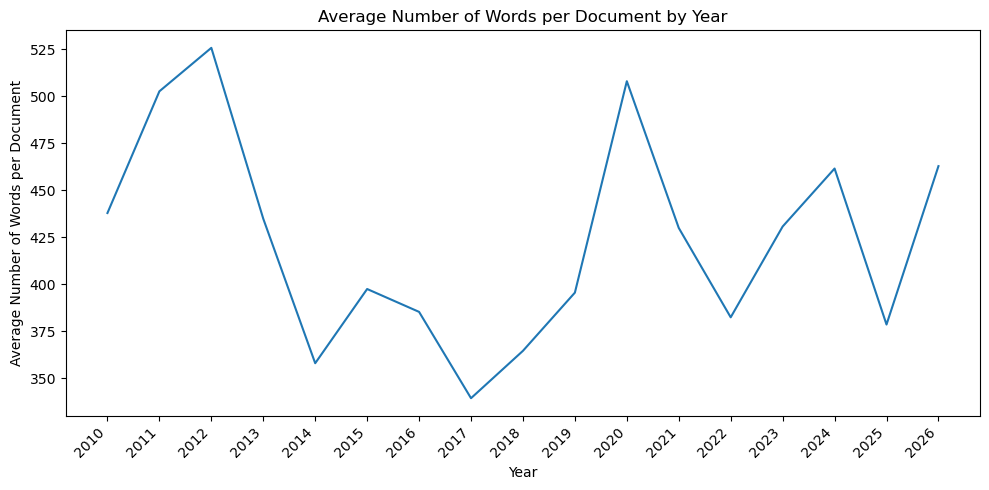

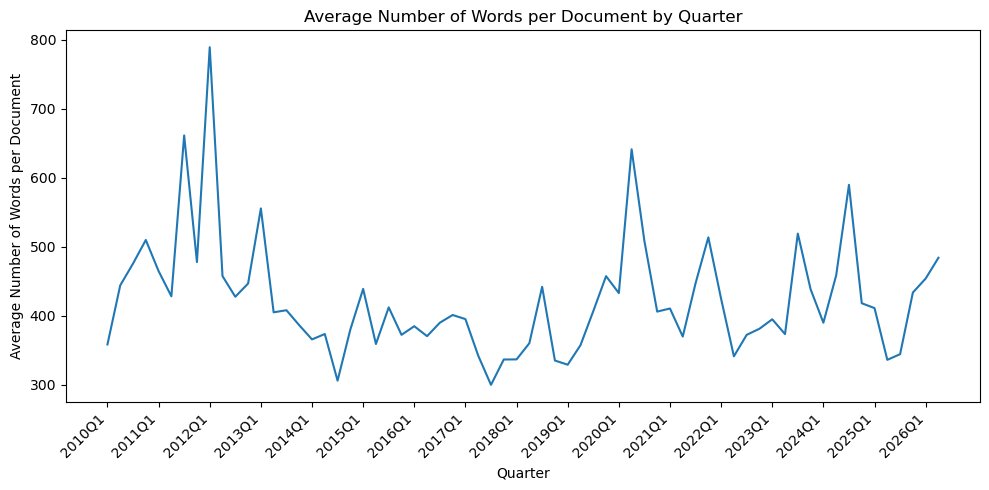

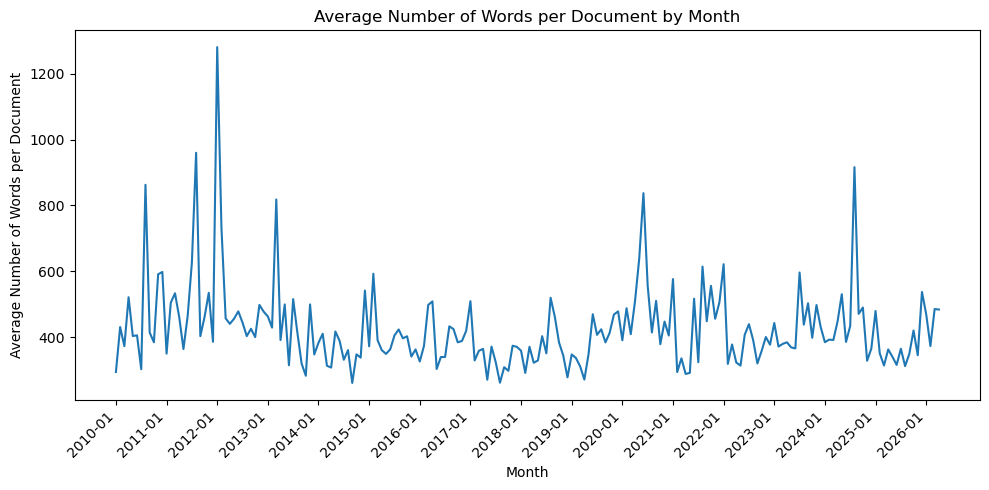

In [13]:
plot_doc_trend(avg_words_by_year, 'Year', 'Average Number of Words per Document', 1)
plot_doc_trend(avg_words_by_quarter, 'Quarter', 'Average Number of Words per Document', 4)
plot_doc_trend(avg_words_by_month, 'Month', 'Average Number of Words per Document', 12)

# 4. Text Preprocessing

In [14]:
# Load the English spaCy model.
# 1) Keep the tagger and lemmatizer for POS filtering and lemmatization.
# 2) Disable parser and NER: they are not needed for basic preprocessing 

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

text_lengths = df['body_text'].astype(str).str.len()
nlp.max_length = max(nlp.max_length, text_lengths.max() + 100)

nlp.pipe_names

['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']

In [15]:
allowed_pos = {'NOUN'}    # Alternatives: 'PROPN', 'ADJ', 'VERB'

domain_stopwords = {
    'fcc', 'federal', 'communication', 'commission',
    'commissioner', 'chairman', 'chairwoman', 'today',
    'announce', 'release', 'statement', 'order', 'rule',
    'rulemaking', 'notice', 'propose', 'proposal', 'adopt',
    'action', 'docket', 'document', 'information', 'background',
    'additional', 'separate', 'approve', 'issue', 'bureau',
    'office', 'media', 'contact', 'washington', 'dc', 'us', 'united', 'state',
    'january', 'february', 'march', 'april', 'may', 'june',
    'july', 'august', 'september', 'october', 'november', 'december'
}

In [16]:
def clean_lemma(lemma):
    '''
    Normalize a lemma returned by spaCy.
    '''
    lemma = lemma.lower().strip()
    lemma = re.sub(r'[^a-z0-9-]', '', lemma)
    return lemma

In [17]:
def preprocess_spacy_doc(doc):
    '''
    Convert one spaCy Doc object into a list of cleaned lemma tokens.
    '''
    tokens = []

    for token in doc:

        # formatting and punctuation tokens
        if token.is_space or token.is_punct or token.is_quote or token.is_bracket:
            continue

        # common or non-topic tokens
        if token.is_stop or token.like_num or token.like_url or token.like_email:
            continue

        if token.pos_ not in allowed_pos:
            continue

        lemma = clean_lemma(token.lemma_)

        if len(lemma) < 2:
            continue

        if lemma in domain_stopwords:
            continue

        tokens.append(lemma)

    return tokens

In [18]:
texts = df['body_text'].tolist()

spacy_tokens = []

for doc in tqdm(nlp.pipe(texts, batch_size=20), total=len(texts)):
    spacy_tokens.append(preprocess_spacy_doc(doc))

df['spacy_tokens'] = spacy_tokens
df['spacy_text'] = df['spacy_tokens'].map(lambda tokens: ' '.join(tokens))
df['spacy_token_count'] = df['spacy_tokens'].map(len)

df[['filename', 'body_word_count', 'body_text', 'spacy_token_count', 'spacy_text']].head()

  0%|          | 0/3188 [00:00<?, ?it/s]

,filename,body_word_count,body_text,spacy_token_count,spacy_text
0,260430_FCC_Proposes_to_Amend_Audible_Crawl_Rul...,288,"Today, the Federal Communications Commission a...",54,people access detail emergency viewer use stre...
1,260430_FCC_Adopts_Rules_to_Enhance_the_Integri...,342,"Today, the Federal Communications Commission a...",88,integrity program bidding applicant program co...
2,260430_FCC_Targets_Covered_List_Entities_Blank...,342,"Today, the Federal Communications Commission v...",67,proceeding entity agency authorization telecom...
3,260430_FCC_Targets_Device_Test_Labs_in_Nations...,406,"Today, the Federal Communications Commission v...",99,recognition device test lab certification body...
4,260430_FCC_Proposes_Strengthening_Know-Your-Cu...,298,In an effort to stop illegal calls before they...,64,effort call people item voice service provider...


In [19]:
preprocessing_summary_dict = {
    'number_of_documents': int(df.shape[0]),
    'min_spacy_token_count': int(df['spacy_token_count'].min()),
    'mean_spacy_token_count': int(round(df['spacy_token_count'].mean())),
    'median_spacy_token_count': int(df['spacy_token_count'].median()),
    'max_spacy_token_count': int(df['spacy_token_count'].max())
}

preprocessing_summary = pd.DataFrame(
    preprocessing_summary_dict.items(),
    columns=['metric', 'value']
)

preprocessing_summary

,metric,value
0,number_of_documents,3188
1,min_spacy_token_count,2
2,mean_spacy_token_count,94
3,median_spacy_token_count,75
4,max_spacy_token_count,1912


# 5. Term Frequency

## 5.1. Basic Term Frequency

In [20]:
all_spacy_tokens = [token for tokens in df['spacy_tokens'] for token in tokens]

term_freq = pd.DataFrame(
    Counter(all_spacy_tokens).most_common(),
    columns=['term', 'count']
)

term_freq

,term,count
0,service,8375
1,consumer,4438
2,provider,4094
3,broadband,3852
4,program,2902
...,...,...
5832,detector,1
5833,remarks,1
5834,inhabitant,1
5835,proving,1


In [21]:
def get_term_frequency_by_period(df, period_col, top_n=20):
    '''
    Calculate raw term frequency by a selected time period.
    >>> period can be: 'year', 'quarter', 'month'
    '''

    doc_term_df = (
        df[['filename', period_col, 'spacy_tokens']]
        .explode('spacy_tokens')
        .dropna(subset=['spacy_tokens'])
        .rename(columns={'spacy_tokens': 'term'})
    )
    
    term_freq_by_period = (
        doc_term_df
        .groupby([period_col, 'term'])
        .size()
        .rename('count')
        .reset_index()
        .sort_values([period_col, 'count'], ascending=[True, False])
    )

    top_terms_by_period = (
        term_freq_by_period
        .groupby(period_col)
        .head(top_n)
        .reset_index(drop=True)
    )
    
    return top_terms_by_period

In [22]:
raw_term_freq_by_year = get_term_frequency_by_period(df, 'year', top_n=20)
raw_term_freq_by_quarter = get_term_frequency_by_period(df, 'quarter', top_n=20)
raw_term_freq_by_month = get_term_frequency_by_period(df, 'month', top_n=20)

In [23]:
raw_term_freq_by_year.head(40)

,year,term,count
0,2010,service,646
1,2010,broadband,485
2,2010,consumer,350
3,2010,complaint,291
4,2010,internet,274
5,2010,network,261
6,2010,inquiry,240
7,2010,access,221
8,2010,provider,209
9,2010,spectrum,205


In [24]:
raw_term_freq_by_quarter.head(40)

,quarter,term,count
0,2010Q1,service,123
1,2010Q1,broadband,121
2,2010Q1,consumer,72
3,2010Q1,internet,65
4,2010Q1,speed,56
5,2010Q1,access,55
6,2010Q1,network,55
7,2010Q1,medium,53
8,2010Q1,workshop,51
9,2010Q1,technology,49


In [25]:
raw_term_freq_by_month.head(40)

,month,term,count
0,2010-01,consumer,45
1,2010-01,radio,25
2,2010-01,service,25
3,2010-01,system,25
4,2010-01,request,23
5,2010-01,workshop,21
6,2010-01,station,20
7,2010-01,effort,19
8,2010-01,medium,19
9,2010-01,internet,18


## 5.2. N-Gram Frequency

## 5.3. TF-IDF